In [10]:
import pandas as pd

# Load the Dimension Tables
customers = pd.read_csv('customers_export.csv')
products = pd.read_csv('products_export.csv')
payments = pd.read_csv('payments_export.csv')

# Load the Fact and Junction Tables
orders = pd.read_csv('orders_export.csv')
order_items = pd.read_csv('order_items_export.csv')

# Syntax Check: .info() shows you the data types and if any 'null' values exist
print(customers.info())
customers.head()
# Recreating your 5-table relational logic
# 1. Join Orders with Customers
df = pd.merge(orders, customers, on='customer_id', how='left')

# 2. Join with Payments to analyze the ₹39K leakage
df = pd.merge(df, payments, on='order_id', how='left')

# 3. Join with Order Items and Products for Category-wise analysis
df = pd.merge(df, order_items, on='order_id', how='left')
df = pd.merge(df, products, on='product_id', how='left')

# Verification: Confirming the 1,400+ transaction records are loaded
print(f"Total Records Loaded: {len(df)}")



<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   age          150 non-null    int64
 3   city         150 non-null    str  
 4   membership   75 non-null     str  
dtypes: int64(2), str(3)
memory usage: 6.0 KB
None
Total Records Loaded: 1442


In [26]:
# Recreating your 5-table relational logic
# 1. Join Orders with Customers
df = pd.merge(orders, customers, on='customer_id', how='left')

# 2. Join with Payments to analyze the ₹39K leakage
df = pd.merge(df, payments, on='order_id', how='left')

# 3. Join with Order Items and Products for Category-wise analysis
df = pd.merge(df, order_items, on='order_id', how='left')
df = pd.merge(df, products, on='product_id', how='left')

# Verification: Confirming the 1,400+ transaction records are loaded
print(f"Total Records Loaded: {len(df)}")




Total Records Loaded: 1442


In [27]:
# Aggregate total revenue by city using your 5-table schema
city_revenue = orders.merge(customers, on='customer_id').groupby('city')['amount'].sum().sort_values(ascending=False)

# Display the top 5 cities
print(city_revenue.head())

city
Delhi        402032.0
Mumbai       246986.0
Bangalore    157390.0
Pune         135495.0
Hyderabad    119969.0
Name: amount, dtype: float64


In [28]:
# Calculate AOV for Members vs. Non-Members
membership_impact = orders.merge(customers, on='customer_id').groupby('membership')['amount'].mean()

print(membership_impact)

membership
Gold      8411.410714
Silver    2926.259804
Name: amount, dtype: float64


In [12]:
import sys
!{sys.executable} -m pip install seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\offic\AppData\Local\Temp\ipykernel_26272\2627029204.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=payments, x='payment_method', palette='viridis')


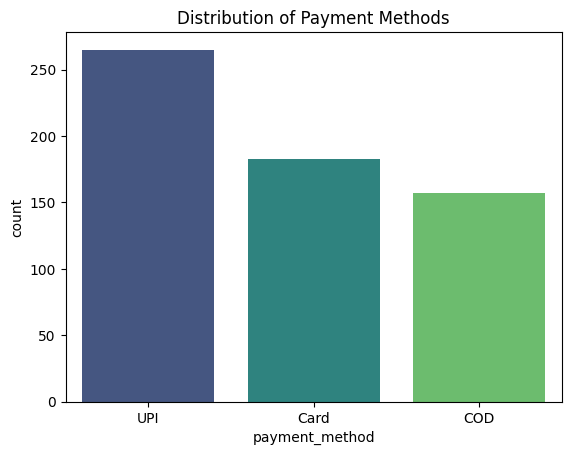

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the distribution of payment methods
sns.countplot(data=payments, x='payment_method', palette='viridis')
plt.title('Distribution of Payment Methods')
plt.show()

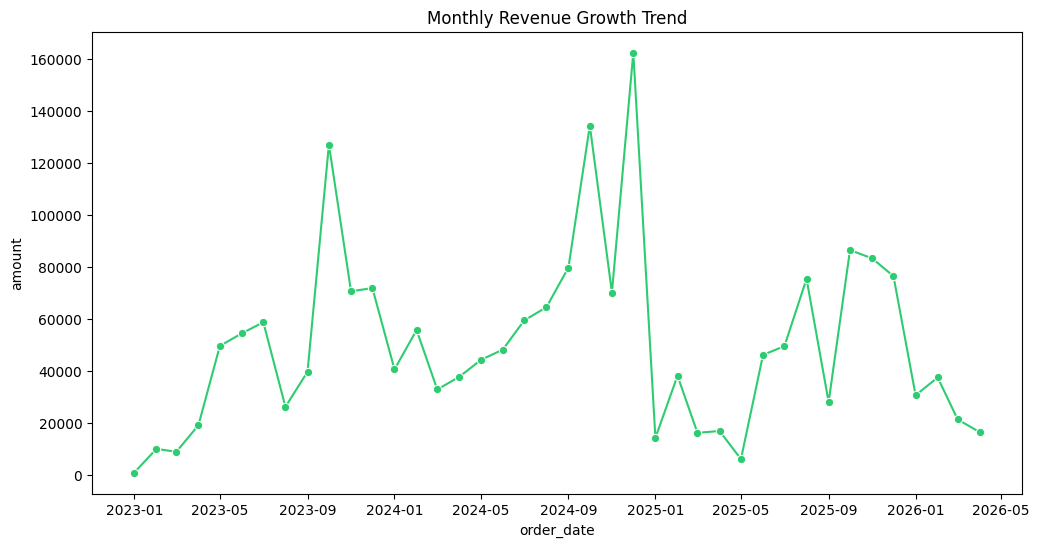

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. RE-LOAD (Ensures variables exist in the current session)
orders = pd.read_csv('orders_export.csv')
customers = pd.read_csv('customers_export.csv')

# 2. RE-MERGE (Defining 'df' clearly)
df = pd.merge(orders, customers, on='customer_id', how='left')

# 3. PREP DATA
df['order_date'] = pd.to_datetime(df['order_date'])
monthly_revenue = df.resample('MS', on='order_date')['amount'].sum().reset_index()

# 4. PLOT
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='order_date', y='amount', marker='o', color='#2ecc71')
plt.title('Monthly Revenue Growth Trend')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge df with payments to get payment_method and payment_status columns
df_with_payments = pd.merge(df, payments, on='order_id', how='left')

# 2. PREP - Use _y suffix for the payment table columns
target_col = 'payment_method_y'
status_col = 'payment_status_y'

pay_counts = df_with_payments.groupby([target_col, status_col]).size().reset_index(name='count')
method_totals = df_with_payments.groupby(target_col).size().reset_index(name='total')
pay_stats = pd.merge(pay_counts, method_totals, on=target_col)
pay_stats['percentage'] = (pay_stats['count'] / pay_stats['total']) * 100

# 3. PLOT
plt.figure(figsize=(12, 6))
sns.barplot(data=pay_stats, x=target_col, y='percentage', hue=status_col, palette='magma')
plt.axhline(90, ls='--', color='red', alpha=0.5)
plt.title('Payment Efficiency: Success vs. Failure Rates')
plt.show()


Columns in df_with_payments:
['order_id', 'customer_id', 'order_date', 'amount', 'status', 'name', 'age', 'city', 'membership', 'payment_id_x', 'payment_method_x', 'payment_status_x', 'order_item_id', 'product_id', 'quantity', 'product_name', 'category', 'price', 'payment_id_y', 'payment_method_y', 'payment_status_y']

First few rows:
   order_id  customer_id  order_date  amount     status          name  age  \
0      1001            1  2024-01-05  2598.0  Completed  Aarav Sharma   28   
1      1002            3  2024-01-08  1299.0  Completed   Rohan Mehta   22   
2      1003            5  2024-01-12  8999.0  Completed   Karan Gupta   45   
3      1004            2  2024-01-15   898.0  Cancelled   Priya Patel   34   
4      1004            2  2024-01-15   898.0  Cancelled   Priya Patel   34   

        city membership  payment_id_x  ... payment_status_x order_item_id  \
0     Mumbai       Gold          2001  ...          Success             1   
1       Pune        NaN          2002  .

KeyError: 'payment_method'